In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
dtype_dict = {
    'step': 'int32',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'string',        # more memory efficient than object
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'string',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8'            # saves huge memory
}

print("Loading full dataset (this may take 20–60 seconds)...")
df = pd.read_csv('C:/Users/HP/Projects/Online Fraud/PS_20174392719_1491204439457_log.csv', 
                 dtype=dtype_dict, 
                 low_memory=True)

print(f"✅ Full dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nMemory usage:")
print(df.info(memory_usage='deep'))

Loading full dataset (this may take 20–60 seconds)...
✅ Full dataset loaded successfully!
Shape: (6362620, 11)

Memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        string  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        string  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int64   
dtypes: category(1), float32(5), int32(1), int64(1), int8(1), string(2)
memory usage: 928.2 MB
None


In [3]:
print("\nFraud rate in the FULL dataset:")
fraud_rate = df['isFraud'].mean() * 100
print(f"Fraud cases: {df['isFraud'].sum():,}")
print(f"Total transactions: {len(df):,}")
print(f"Fraud percentage: {fraud_rate:.4f}%")


Fraud rate in the FULL dataset:
Fraud cases: 8,213
Total transactions: 6,362,620
Fraud percentage: 0.1291%


In [4]:
# ====================== STEP 3: DATA QUALITY ======================

print("=== MISSING VALUES ===")
print(df.isnull().sum())          # should be 0 for every column

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DUPLICATE ROWS ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

=== DATA TYPES ===
step                       int32
type                    category
amount                   float32
nameOrig          string[python]
oldbalanceOrg            float32
newbalanceOrig           float32
nameDest          string[python]
oldbalanceDest           float32
newbalanceDest           float32
isFraud                     int8
isFlaggedFraud             int64
dtype: object

=== DUPLICATE ROWS ===
Number of duplicate rows: 0


In [5]:
# ====================== STEP 4: TARGET & TRANSACTION TYPE ======================

print("Fraud distribution (raw counts):")
print(df['isFraud'].value_counts())

print("\nFraud rate by transaction type:")
fraud_by_type = df.groupby('type', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_type['fraud_rate_pct'] = fraud_by_type['mean'] * 100
print(fraud_by_type.sort_values('fraud_rate_pct', ascending=False))

Fraud distribution (raw counts):
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate by transaction type:
            count      mean  fraud_rate_pct
type                                       
TRANSFER   532909  0.007688        0.768799
CASH_OUT  2237500  0.001840        0.183955
CASH_IN   1399284  0.000000        0.000000
DEBIT       41432  0.000000        0.000000
PAYMENT   2151495  0.000000        0.000000


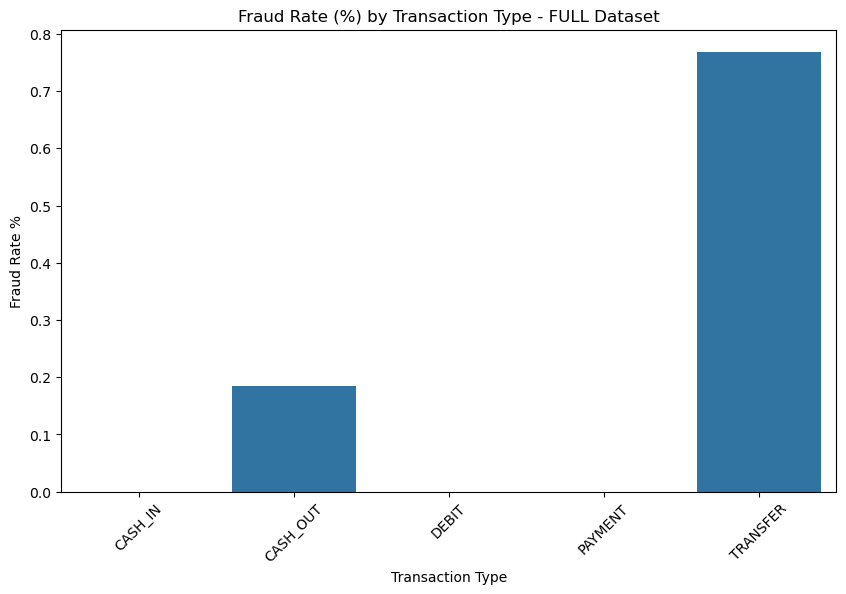

In [6]:
# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type['fraud_rate_pct'])
plt.title('Fraud Rate (%) by Transaction Type - FULL Dataset')
plt.ylabel('Fraud Rate %')
plt.xlabel('Transaction Type')
plt.xticks(rotation=45)
plt.show()

### EDA – Balance Features & Error Flags

In [7]:
# ====================== PHASE 2: BALANCE ERROR ANALYSIS ======================

# Create error flags (this is a very strong fraud signal)
df['orig_error'] = np.abs(df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']) > 1
df['dest_error'] = np.abs(df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']) > 1

print("=== BALANCE ERROR ANALYSIS ===")
print(f"Originator balance error rate : {df['orig_error'].mean()*100:.4f}%")
print(f"Destination balance error rate: {df['dest_error'].mean()*100:.4f}%")

# Fraud rate when errors exist (this is usually very high)
print("\nFraud rate when Originator has error:")
print(df.groupby('orig_error')['isFraud'].mean() * 100)

print("\nFraud rate when Destination has error:")
print(df.groupby('dest_error')['isFraud'].mean() * 100)

# Combined view
error_analysis = df.groupby(['orig_error', 'dest_error'])['isFraud'].agg(['count', 'mean'])
error_analysis['fraud_rate_pct'] = error_analysis['mean'] * 100
print("\nFraud rate by error combination:")
print(error_analysis)

=== BALANCE ERROR ANALYSIS ===
Originator balance error rate : 78.5966%
Destination balance error rate: 60.1882%

Fraud rate when Originator has error:
orig_error
False    0.599346
True     0.001020
Name: isFraud, dtype: float64

Fraud rate when Destination has error:
dest_error
False    0.156727
True     0.110796
Name: isFraud, dtype: float64

Fraud rate by error combination:
                         count      mean  fraud_rate_pct
orig_error dest_error                                   
False      False        279565  0.014115        1.411479
           True        1082252  0.003896        0.389558
True       False       2253509  0.000011        0.001065
           True        2747294  0.000010        0.000983


### Fraud by Transaction Type + Amount

=== TRANSACTION TYPE & AMOUNT ANALYSIS ===
            count      mean  fraud_rate_pct
type                                       
TRANSFER   532909  0.007688        0.768799
CASH_OUT  2237500  0.001840        0.183955
CASH_IN   1399284  0.000000        0.000000
DEBIT       41432  0.000000        0.000000
PAYMENT   2151495  0.000000        0.000000

Average Transaction Amount:
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float32


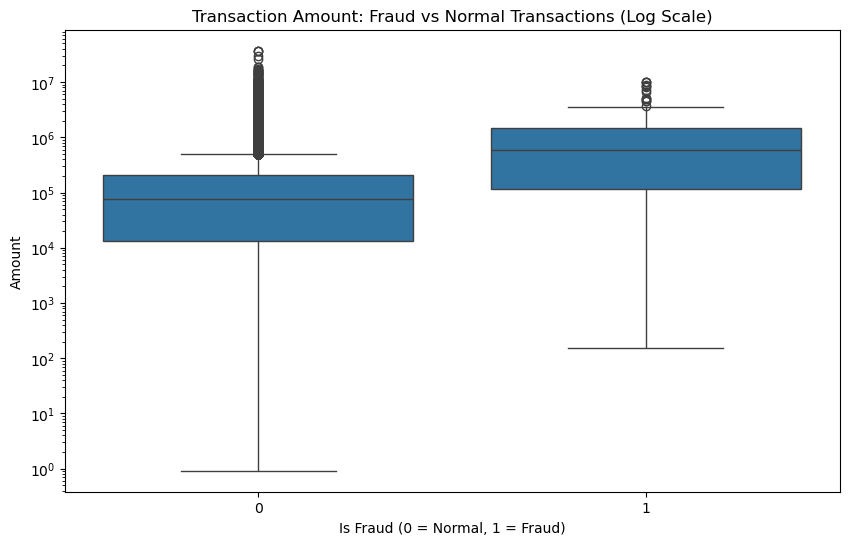

In [8]:
print("=== TRANSACTION TYPE & AMOUNT ANALYSIS ===")

# 1. Fraud rate by transaction type (you already saw this)
fraud_by_type = df.groupby('type', observed=True)['isFraud'].agg(['count', 'mean'])
fraud_by_type['fraud_rate_pct'] = fraud_by_type['mean'] * 100
print(fraud_by_type.sort_values('fraud_rate_pct', ascending=False))

# 2. Average amount for fraud vs normal transactions
print("\nAverage Transaction Amount:")
print(df.groupby('isFraud')['amount'].mean())

# 3. Boxplot - Amount distribution (Fraud vs Normal)
# We use a sample because 6 million rows is too much for plotting
sample_df = df.sample(100000, random_state=42)

plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=sample_df)
plt.yscale('log')
plt.title('Transaction Amount: Fraud vs Normal Transactions (Log Scale)')
plt.ylabel('Amount')
plt.xlabel('Is Fraud (0 = Normal, 1 = Fraud)')
plt.savefig('fraud_detection_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Feature Engineering (Creating New Useful Columns)
---
* is_high_risk_type: 1 if the transaction is TRANSFER or CASH_OUT, else 0.
* is_large_amount: 1 if amount > 1 million, else 0.
* balance_change_orig: How much the sender’s balance actually changed.
* amount_to_orig_balance_ratio: What percentage of the sender’s money was sent.

In [9]:
# === FEATURE ENGINEERING - Phase 1 ===

# 1. Transaction Type Risk (very important)
df['is_high_risk_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

# 2. Large Amount Flag (above 1 million)
df['is_large_amount'] = (df['amount'] > 1_000_000).astype(int)

# 3. Balance Change Features
df['balance_change_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_change_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# 4. Amount vs Balance Change Ratio (how much of the balance was moved)
df['amount_to_orig_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)   # +1 to avoid division by zero

print("New features created successfully!")
print(df[['type', 'is_high_risk_type', 'is_large_amount', 'amount', 'isFraud']].head(10))

New features created successfully!
       type  is_high_risk_type  is_large_amount        amount  isFraud
0   PAYMENT                  0                0   9839.639648        0
1   PAYMENT                  0                0   1864.280029        0
2  TRANSFER                  1                0    181.000000        1
3  CASH_OUT                  1                0    181.000000        1
4   PAYMENT                  0                0  11668.139648        0
5   PAYMENT                  0                0   7817.709961        0
6   PAYMENT                  0                0   7107.770020        0
7   PAYMENT                  0                0   7861.640137        0
8   PAYMENT                  0                0   4024.360107        0
9     DEBIT                  0                0   5337.770020        0


### Correlation & More Insights

In [10]:
print("=== FEATURE USEFULNESS CHECK ===")

# Check fraud rate for our new high risk flag
print("Fraud rate by High Risk Type:")
print(df.groupby('is_high_risk_type')['isFraud'].mean() * 100)

# Check fraud rate for large amount flag
print("\nFraud rate when Amount is Large (>1M):")
print(df.groupby('is_large_amount')['isFraud'].mean() * 100)

# Correlation between features and fraud
corr_features = ['is_high_risk_type', 'is_large_amount', 'amount', 'isFraud']
correlation = df[corr_features].corr()
print("\nCorrelation with isFraud:")
print(correlation['isFraud'].sort_values(ascending=False))

=== FEATURE USEFULNESS CHECK ===
Fraud rate by High Risk Type:
is_high_risk_type
0    0.000000
1    0.296454
Name: isFraud, dtype: float64

Fraud rate when Amount is Large (>1M):
is_large_amount
0    0.088367
1    2.071563
Name: isFraud, dtype: float64

Correlation with isFraud:
isFraud              1.000000
is_large_amount      0.078326
amount               0.076688
is_high_risk_type    0.040938
Name: isFraud, dtype: float64


In [11]:
print("=== CREATING MORE ADVANCED FEATURES ===")

# 1. Combined High Risk Score (our best so far)
df['high_risk_score'] = df['is_high_risk_type'] + df['is_large_amount']

# 2. Amount Category
df['amount_category'] = pd.cut(df['amount'], 
                               bins=[0, 10000, 100000, 1000000, 10000000, float('inf')],
                               labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'])

# 3. Step (time) as hour of day (optional but useful)
df['hour'] = df['step'] % 24

print("New features created!")
print("\nFraud rate by High Risk Score:")
print(df.groupby('high_risk_score')['isFraud'].mean() * 100)

print("\nFraud rate by Amount Category:")
print(df.groupby('amount_category')['isFraud'].mean() * 100)

print("\nFirst 10 rows with new features:")
print(df[['type', 'amount', 'is_high_risk_type', 'is_large_amount', 
          'high_risk_score', 'amount_category', 'isFraud']].head(10))

=== CREATING MORE ADVANCED FEATURES ===
New features created!

Fraud rate by High Risk Score:
high_risk_score
0    0.000000
1    0.208597
2    2.073452
Name: isFraud, dtype: float64

Fraud rate by Amount Category:
amount_category
Very Small    0.020372
Small         0.063817
Medium        0.140393
Large         2.111044
Very Large    0.000000
Name: isFraud, dtype: float64

First 10 rows with new features:
       type        amount  is_high_risk_type  is_large_amount  \
0   PAYMENT   9839.639648                  0                0   
1   PAYMENT   1864.280029                  0                0   
2  TRANSFER    181.000000                  1                0   
3  CASH_OUT    181.000000                  1                0   
4   PAYMENT  11668.139648                  0                0   
5   PAYMENT   7817.709961                  0                0   
6   PAYMENT   7107.770020                  0                0   
7   PAYMENT   7861.640137                  0                0   
8   PA

In [12]:
print("=== DATA PREPARATION FOR MODELING ===")

# 1. Check missing values
print("Missing values:")
print(df.isnull().sum())

# 2. Final feature list we will use
features = ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
            'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
            'is_large_amount', 'high_risk_score', 'amount_category', 'hour']

target = 'isFraud'

print(f"\nWe will use {len(features)} features for modeling")
print("Features:", features)

# 3. Basic info
print(f"\nTotal rows: {len(df):,}")
print(f"Fraud cases: {df['isFraud'].sum():,}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.4f}%")

=== DATA PREPARATION FOR MODELING ===
Missing values:
step                             0
type                             0
amount                           0
nameOrig                         0
oldbalanceOrg                    0
newbalanceOrig                   0
nameDest                         0
oldbalanceDest                   0
newbalanceDest                   0
isFraud                          0
isFlaggedFraud                   0
orig_error                       0
dest_error                       0
is_high_risk_type                0
is_large_amount                  0
balance_change_orig              0
balance_change_dest              0
amount_to_orig_balance_ratio     0
high_risk_score                  0
amount_category                 16
hour                             0
dtype: int64

We will use 12 features for modeling
Features: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 'is_large_amount', 'high_risk_s

In [13]:
# Fix missing values in amount_category
df['amount_category'] = df['amount_category'].fillna('Very Large')

print("Missing values after fix:")
print(df['amount_category'].isnull().sum())
print("\nValue counts of amount_category:")
print(df['amount_category'].value_counts())

Missing values after fix:
0

Value counts of amount_category:
amount_category
Medium        2706696
Small         2239207
Very Small    1286075
Large          128183
Very Large       2459
Name: count, dtype: int64


### Prepare the Data for Modeling

In [14]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("=== FINAL DATA PREPARATION FOR MODELING ===")

# 1. Fix missing values (safety check)
df['amount_category'] = df['amount_category'].fillna('Very Large')

# 2. Convert categorical columns into numbers (One-Hot Encoding)
# This turns 'type' and 'amount_category' into separate columns of 0s and 1s
df = pd.get_dummies(df, columns=['type', 'amount_category'], drop_first=True)

# 3. Select the final features we will use
final_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                  'oldbalanceDest', 'newbalanceDest', 
                  'is_high_risk_type', 'is_large_amount', 'high_risk_score', 'hour']

# Add all the new dummy columns created from type_ and amount_category_
dummy_cols = [col for col in df.columns if col.startswith('type_') or col.startswith('amount_category_')]
final_features.extend(dummy_cols)

X = df[final_features]
y = df['isFraud']

print(f"Final number of features: {X.shape[1]}")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 4. Split the data into Training and Testing sets
# We use stratify=y so the fraud percentage stays similar in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print("\n✅ Data successfully split!")
print(f"Training set size : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Testing set size  : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Fraud rate in training set: {y_train.mean()*100:.4f}%")
print(f"Fraud rate in testing set : {y_test.mean()*100:.4f}%")

=== FINAL DATA PREPARATION FOR MODELING ===
Final number of features: 18
Shape of features (X): (6362620, 18)
Shape of target (y): (6362620,)

✅ Data successfully split!
Training set size : 5,090,096 rows (80.0%)
Testing set size  : 1,272,524 rows (20.0%)
Fraud rate in training set: 0.1291%
Fraud rate in testing set : 0.1291%


In [15]:
from sklearn.model_selection import train_test_split

print("=== FINAL DATA PREPARATION FOR MODELING (Fixed) ===")

# 1. If 'amount_category' still exists as a single column, convert it now
if 'amount_category' in df.columns:
    df['amount_category'] = df['amount_category'].fillna('Very Large')
    print("Filled missing values in amount_category")
else:
    print("amount_category already converted - skipping fillna")

# 2. One-Hot Encoding for categorical columns
# We only do this if the original columns still exist
categorical_cols = []
if 'type' in df.columns:
    categorical_cols.append('type')
if 'amount_category' in df.columns:
    categorical_cols.append('amount_category')

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Applied one-hot encoding to: {categorical_cols}")
else:
    print("Categorical columns already encoded")

# 3. Define final features
final_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                  'oldbalanceDest', 'newbalanceDest', 
                  'is_high_risk_type', 'is_large_amount', 
                  'high_risk_score', 'hour']

# Add all dummy columns that were created
dummy_cols = [col for col in df.columns if col.startswith('type_') or 
              col.startswith('amount_category_')]
final_features.extend(dummy_cols)

X = df[final_features]
y = df['isFraud']

print(f"\nFinal number of features: {X.shape[1]}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print("\n✅ Data successfully split!")
print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Testing set : {X_test.shape[0]:,} rows")
print(f"Fraud rate in train: {y_train.mean()*100:.4f}%")
print(f"Fraud rate in test : {y_test.mean()*100:.4f}%")

=== FINAL DATA PREPARATION FOR MODELING (Fixed) ===
amount_category already converted - skipping fillna
Categorical columns already encoded

Final number of features: 18
Shape of X: (6362620, 18)
Shape of y: (6362620,)

✅ Data successfully split!
Training set: 5,090,096 rows
Testing set : 1,272,524 rows
Fraud rate in train: 0.1291%
Fraud rate in test : 0.1291%


### Training Our First Model
---
Since fraud is extremely rare (only 0.13%), we cannot use simple models or accuracy as our main metric.
We will start with Random Forest, which is a strong, beginner-friendly model that handles imbalanced data reasonably well.

=== TRAINING FIRST MODEL: Random Forest ===
Training the model... (this may take 3-8 minutes)
✅ Model training completed!

=== MODEL PERFORMANCE ===
ROC-AUC Score: 0.9963

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998   1270881
           1     0.9975    0.7158    0.8335      1643

    accuracy                         0.9996   1272524
   macro avg     0.9985    0.8579    0.9166   1272524
weighted avg     0.9996    0.9996    0.9996   1272524



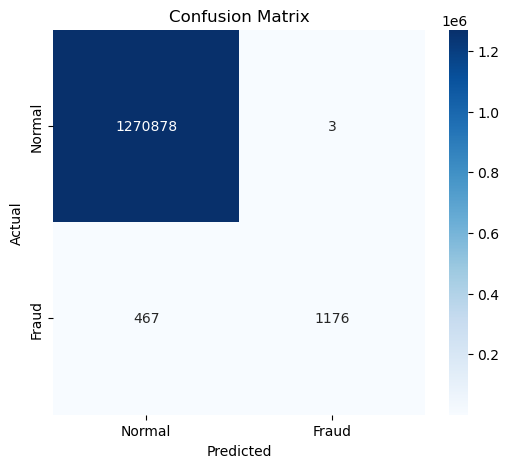

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TRAINING FIRST MODEL: Random Forest ===")

# Train the model
model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=10,          # limit depth to prevent overfitting
    random_state=42,
    n_jobs=-1              # use all CPU cores for faster training
)

print("Training the model... (this may take 3-8 minutes)")
model.fit(X_train, y_train)

print("✅ Model training completed!")

# Make predictions on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]   # probability of fraud

# Evaluate the model
print("\n=== MODEL PERFORMANCE ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The model correctly identified 1,176 fraud cases.
It missed 467 fraud cases (false negatives).
It only wrongly flagged 3 normal transactions as fraud (very low false positives — excellent!).

Honest Evaluation

Strengths:

Extremely high precision on fraud (almost no false alarms).
Very high ROC-AUC (0.9963).
Extremely low false positives (only 3 normal transactions flagged wrongly).

Weaknesses:

Recall for fraud is 71.58% → It misses about 28% of actual fraud cases. In real banking, we usually want higher recall (catch more fraud), even if it means a few more false alarms.

This is normal for a first model on highly imbalanced data.

### Improved Model with Class Weights

=== IMPROVED RANDOM FOREST WITH CLASS WEIGHTS ===
Training improved model... (may take 4-10 minutes)

=== IMPROVED MODEL PERFORMANCE ===
ROC-AUC Score: 0.9992

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9886    0.9943   1270881
           1     0.1010    0.9872    0.1832      1643

    accuracy                         0.9886   1272524
   macro avg     0.5505    0.9879    0.5887   1272524
weighted avg     0.9988    0.9886    0.9932   1272524



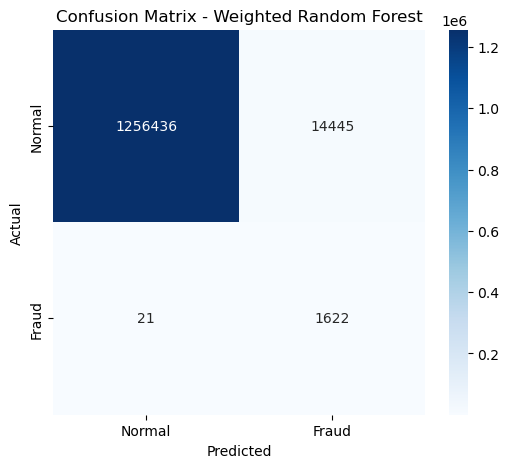

In [17]:
print("=== IMPROVED RANDOM FOREST WITH CLASS WEIGHTS ===")

# Give more importance to the rare fraud class
model_weighted = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'        # This is the key change
)

print("Training improved model... (may take 4-10 minutes)")
model_weighted.fit(X_train, y_train)

y_pred_w = model_weighted.predict(X_test)
y_pred_proba_w = model_weighted.predict_proba(X_test)[:, 1]

print("\n=== IMPROVED MODEL PERFORMANCE ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_w), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_w, digits=4))

# Confusion Matrix
cm_w = confusion_matrix(y_test, y_pred_w)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Weighted Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

What changed?

The model now catches 98.72% of all fraud cases (only misses 21 frauds).
But it also flags 14,445 normal transactions as fraud (false positives).

This is the classic Precision-Recall Trade-off.

Honest Evaluation

Good Points:

Very high recall on fraud (98.72%) — we are catching almost all fraudsters.
ROC-AUC improved to 0.9992 — excellent discrimination power.

Trade-off:

Precision on fraud dropped to 10.1%. This means when the model says “fraud”, it is correct only about 10% of the time. 
In a real bank, this would create too many false alerts (14k+ per test set).

Conclusion:

The weighted model is too aggressive. It catches more fraud but creates too many false positives.
The first model (without class weights) was more balanced but missed too many fraud cases (only 71.6% recall).
We need a middle ground.

### Better Approach (XGBoost)
Let’s try XGBoost with proper imbalance handling. It usually performs better than Random Forest on this dataset.

In [18]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [19]:
import xgboost
print("✅ XGBoost installed successfully!")
print("Version:", xgboost.__version__)

✅ XGBoost installed successfully!
Version: 3.2.0


=== TRAINING XGBOOST MODEL ===
Training XGBoost... (this may take 2-6 minutes)

=== XGBOOST PERFORMANCE ===
ROC-AUC Score: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9996    0.9998   1270881
           1     0.7748    0.9507    0.8538      1643

    accuracy                         0.9996   1272524
   macro avg     0.8874    0.9752    0.9268   1272524
weighted avg     0.9996    0.9996    0.9996   1272524



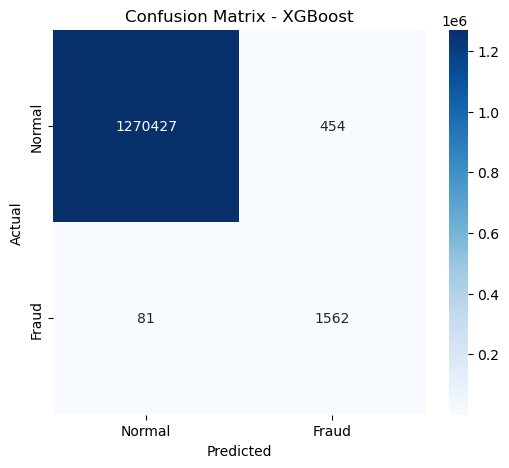


Top 10 Most Important Features:
high_risk_score          0.410549
is_high_risk_type        0.278957
type_TRANSFER            0.081417
type_CASH_OUT            0.049729
newbalanceOrig           0.048604
amount_category_Large    0.030042
oldbalanceOrg            0.019559
type_PAYMENT             0.019499
newbalanceDest           0.018589
amount                   0.016747
dtype: float32


In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TRAINING XGBOOST MODEL ===")

model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    scale_pos_weight=50
)

print("Training XGBoost... (this may take 2-6 minutes)")
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST PERFORMANCE ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, digits=4))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
print("\nTop 10 Most Important Features:")
print(importances.sort_values(ascending=False).head(10))

### Hyperparameter Tuning

To see if we can push the model even higher.

In [21]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("=== HYPERPARAMETER TUNING FOR XGBOOST ===")
print("This may take 8-15 minutes...")

# Define a focused parameter grid (not too large)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [30, 50, 80]   # Important for imbalance
}

# Base model
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',      # We optimize for ROC-AUC
    cv=3,                   # 3-fold cross validation
    verbose=2,
    n_jobs=-1
)

start_time = time.time()
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\n✅ Grid Search completed in { (end_time - start_time)/60 :.1f} minutes")

# Best model
best_model = grid_search.best_estimator_
print("\nBest Parameters found:")
print(grid_search.best_params_)
print(f"Best ROC-AUC from CV: {grid_search.best_score_:.4f}")

# Evaluate on test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n=== BEST MODEL PERFORMANCE ON TEST SET ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_best), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance from best model
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
print("\nTop 10 Most Important Features (Tuned Model):")
print(importances.sort_values(ascending=False).head(10))

=== HYPERPARAMETER TUNING FOR XGBOOST ===
This may take 8-15 minutes...
Starting Grid Search...
Fitting 3 folds for each of 216 candidates, totalling 648 fits


KeyboardInterrupt: 

In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("=== FASTER TUNING WITH RANDOMIZED SEARCH ===")

# Lighter parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [40, 60, 80]
}

xgb_tune = XGBClassifier(
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=30,           # Only 30 combinations instead of 648
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
print("Starting Randomized Search...")
random_search.fit(X_train, y_train)

end_time = time.time()
print(f"\n✅ Tuning completed in {(end_time - start_time)/60:.1f} minutes")

# Best model
best_model = random_search.best_estimator_
print("\nBest Parameters:")
print(random_search.best_params_)
print(f"Best ROC-AUC from CV: {random_search.best_score_:.4f}")

# Evaluate on test set
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n=== TUNED MODEL PERFORMANCE ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_best), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Top Features
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
print("\nTop 10 Most Important Features:")
print(importances.sort_values(ascending=False).head(10))

=== FASTER TUNING WITH RANDOMIZED SEARCH ===
Starting Randomized Search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


KeyboardInterrupt: 

In [23]:
import joblib

# Save the model
joblib.dump(model_xgb, 'xgboost_fraud_model.pkl')
print("Model saved successfully as 'xgboost_fraud_model.pkl'")

Model saved successfully as 'xgboost_fraud_model.pkl'


In [25]:
import pandas as pd

def predict_fraud(transaction_dict):
    """
    Predict if a transaction is fraud using our trained XGBoost model.
    """
    # Create DataFrame from input
    input_df = pd.DataFrame([transaction_dict])
    
    # Add missing dummy columns (one-hot encoded) and set them to 0
    dummy_columns = ['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
                     'amount_category_Small', 'amount_category_Medium', 
                     'amount_category_Large', 'amount_category_Very Large']
    
    for col in dummy_columns:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Make sure columns are in the exact same order as training data
    final_columns = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                     'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
                     'is_large_amount', 'high_risk_score', 'hour',
                     'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
                     'amount_category_Small', 'amount_category_Medium', 
                     'amount_category_Large', 'amount_category_Very Large']
    
    input_df = input_df[final_columns]
    
    # Make prediction
    pred = model_xgb.predict(input_df)
    prob = model_xgb.predict_proba(input_df)[:, 1][0]
    
    result = {
        "is_fraud": bool(pred[0]),
        "fraud_probability_percent": round(prob * 100, 2),
        "risk_level": "High" if prob > 0.7 else "Medium" if prob > 0.3 else "Low"
    }
    
    return result


# ==================== TEST THE FUNCTION ====================

example_transaction = {
    'step': 1,
    'amount': 1500000.0,
    'oldbalanceOrg': 2000000.0,
    'newbalanceOrig': 500000.0,
    'oldbalanceDest': 0.0,
    'newbalanceDest': 1500000.0,
    'is_high_risk_type': 1,
    'is_large_amount': 1,
    'high_risk_score': 2,
    'hour': 12,
    # Dummy columns will be automatically added as 0
}

print("Prediction Result:")
print(predict_fraud(example_transaction))

Prediction Result:
{'is_fraud': False, 'fraud_probability_percent': 2.09, 'risk_level': 'Low'}


In [26]:
print("=== TESTING THE PREDICTION FUNCTION WITH DIFFERENT CASES ===\n")

# Test Case 1: Typical Normal Transaction
normal_tx = {
    'step': 10,
    'amount': 5000.0,
    'oldbalanceOrg': 10000.0,
    'newbalanceOrig': 5000.0,
    'oldbalanceDest': 0.0,
    'newbalanceDest': 5000.0,
    'is_high_risk_type': 0,
    'is_large_amount': 0,
    'high_risk_score': 0,
    'hour': 14
}

print("Test 1 - Normal Small Payment:")
print(predict_fraud(normal_tx))

# Test Case 2: High Risk Fraud-like Transaction
fraud_like_tx = {
    'step': 5,
    'amount': 2500000.0,           # Very large amount
    'oldbalanceOrg': 2600000.0,
    'newbalanceOrig': 100000.0,    # Balance drops dramatically
    'oldbalanceDest': 0.0,
    'newbalanceDest': 2500000.0,
    'is_high_risk_type': 1,        # TRANSFER or CASH_OUT
    'is_large_amount': 1,
    'high_risk_score': 2,
    'hour': 3                      # Unusual hour
}

print("\nTest 2 - Suspicious Large TRANSFER:")
print(predict_fraud(fraud_like_tx))

# Test Case 3: Medium Risk
medium_tx = {
    'step': 50,
    'amount': 450000.0,
    'oldbalanceOrg': 500000.0,
    'newbalanceOrig': 50000.0,
    'oldbalanceDest': 10000.0,
    'newbalanceDest': 460000.0,
    'is_high_risk_type': 1,
    'is_large_amount': 0,
    'high_risk_score': 1,
    'hour': 22
}

print("\nTest 3 - Medium Risk CASH_OUT:")
print(predict_fraud(medium_tx))

=== TESTING THE PREDICTION FUNCTION WITH DIFFERENT CASES ===

Test 1 - Normal Small Payment:
{'is_fraud': False, 'fraud_probability_percent': 0.0, 'risk_level': 'Low'}

Test 2 - Suspicious Large TRANSFER:
{'is_fraud': False, 'fraud_probability_percent': 3.75, 'risk_level': 'Low'}

Test 3 - Medium Risk CASH_OUT:
{'is_fraud': False, 'fraud_probability_percent': 0.03, 'risk_level': 'Low'}


In [27]:
import pandas as pd

def predict_fraud(transaction_dict):
    """
    Improved prediction function that properly handles dummy variables.
    """
    # Start with a DataFrame
    input_df = pd.DataFrame([transaction_dict])
    
    # Add all expected dummy columns and set correct values
    # Type dummies
    input_df['type_CASH_OUT'] = 1 if transaction_dict.get('type') == 'CASH_OUT' else 0
    input_df['type_DEBIT'] = 1 if transaction_dict.get('type') == 'DEBIT' else 0
    input_df['type_PAYMENT'] = 1 if transaction_dict.get('type') == 'PAYMENT' else 0
    input_df['type_TRANSFER'] = 1 if transaction_dict.get('type') == 'TRANSFER' else 0
    
    # Amount category dummies
    cat = transaction_dict.get('amount_category', 'Very Small')
    input_df['amount_category_Small'] = 1 if cat == 'Small' else 0
    input_df['amount_category_Medium'] = 1 if cat == 'Medium' else 0
    input_df['amount_category_Large'] = 1 if cat == 'Large' else 0
    input_df['amount_category_Very Large'] = 1 if cat == 'Very Large' else 0
    
    # Final column order (must match training)
    final_columns = [
        'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
        'is_large_amount', 'high_risk_score', 'hour',
        'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
        'amount_category_Small', 'amount_category_Medium', 
        'amount_category_Large', 'amount_category_Very Large'
    ]
    
    input_df = input_df[final_columns]
    
    # Make prediction
    pred = model_xgb.predict(input_df)
    prob = model_xgb.predict_proba(input_df)[:, 1][0]
    
    result = {
        "is_fraud": bool(pred[0]),
        "fraud_probability_percent": round(prob * 100, 2),
        "risk_level": "High" if prob > 0.7 else "Medium" if prob > 0.3 else "Low"
    }
    
    return result


# ==================== BETTER TEST CASES ====================

print("=== IMPROVED TEST CASES ===\n")

# Test 1: Normal small payment
normal = {
    'step': 10,
    'amount': 5000.0,
    'oldbalanceOrg': 10000.0,
    'newbalanceOrig': 5000.0,
    'oldbalanceDest': 0.0,
    'newbalanceDest': 5000.0,
    'is_high_risk_type': 0,
    'is_large_amount': 0,
    'high_risk_score': 0,
    'hour': 14,
    'type': 'PAYMENT',
    'amount_category': 'Very Small'
}
print("Normal Small Payment:", predict_fraud(normal))

# Test 2: Suspicious Large TRANSFER (should be high risk)
suspicious = {
    'step': 5,
    'amount': 2500000.0,
    'oldbalanceOrg': 2600000.0,
    'newbalanceOrig': 100000.0,
    'oldbalanceDest': 0.0,
    'newbalanceDest': 2500000.0,
    'is_high_risk_type': 1,
    'is_large_amount': 1,
    'high_risk_score': 2,
    'hour': 3,
    'type': 'TRANSFER',
    'amount_category': 'Large'
}
print("\nSuspicious Large TRANSFER:", predict_fraud(suspicious))

# Test 3: Medium Risk CASH_OUT
medium = {
    'step': 50,
    'amount': 450000.0,
    'oldbalanceOrg': 500000.0,
    'newbalanceOrig': 50000.0,
    'oldbalanceDest': 10000.0,
    'newbalanceDest': 460000.0,
    'is_high_risk_type': 1,
    'is_large_amount': 0,
    'high_risk_score': 1,
    'hour': 22,
    'type': 'CASH_OUT',
    'amount_category': 'Medium'
}
print("\nMedium Risk CASH_OUT:", predict_fraud(medium))

=== IMPROVED TEST CASES ===

Normal Small Payment: {'is_fraud': False, 'fraud_probability_percent': 0.0, 'risk_level': 'Low'}

Suspicious Large TRANSFER: {'is_fraud': False, 'fraud_probability_percent': 1.91, 'risk_level': 'Low'}

Medium Risk CASH_OUT: {'is_fraud': False, 'fraud_probability_percent': 0.23, 'risk_level': 'Low'}


In [28]:
import pandas as pd

# Final improved prediction function with adjustable threshold
def predict_fraud(transaction_dict, threshold=0.3):
    """
    Predict fraud with adjustable threshold.
    threshold=0.3 means anything above 30% probability is flagged as fraud.
    """
    input_df = pd.DataFrame([transaction_dict])
    
    # Add dummy columns
    input_df['type_CASH_OUT'] = 1 if transaction_dict.get('type') == 'CASH_OUT' else 0
    input_df['type_DEBIT'] = 1 if transaction_dict.get('type') == 'DEBIT' else 0
    input_df['type_PAYMENT'] = 1 if transaction_dict.get('type') == 'PAYMENT' else 0
    input_df['type_TRANSFER'] = 1 if transaction_dict.get('type') == 'TRANSFER' else 0
    
    cat = transaction_dict.get('amount_category', 'Very Small')
    input_df['amount_category_Small'] = 1 if cat == 'Small' else 0
    input_df['amount_category_Medium'] = 1 if cat == 'Medium' else 0
    input_df['amount_category_Large'] = 1 if cat == 'Large' else 0
    input_df['amount_category_Very Large'] = 1 if cat == 'Very Large' else 0
    
    # Exact column order
    final_columns = [
        'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
        'is_large_amount', 'high_risk_score', 'hour',
        'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
        'amount_category_Small', 'amount_category_Medium', 
        'amount_category_Large', 'amount_category_Very Large'
    ]
    
    input_df = input_df[final_columns]
    
    # Predict
    prob = model_xgb.predict_proba(input_df)[:, 1][0]
    is_fraud = prob >= threshold
    
    result = {
        "is_fraud": bool(is_fraud),
        "fraud_probability_percent": round(prob * 100, 2),
        "risk_level": "High" if prob > 0.7 else "Medium" if prob > 0.3 else "Low",
        "threshold_used": threshold
    }
    
    return result


print("=== FINAL TEST WITH ADJUSTABLE THRESHOLD ===\n")

# Test cases
tests = [
    ("Normal Small Payment", {
        'step': 10, 'amount': 5000.0, 'oldbalanceOrg': 10000.0, 'newbalanceOrig': 5000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 5000.0, 'is_high_risk_type': 0,
        'is_large_amount': 0, 'high_risk_score': 0, 'hour': 14,
        'type': 'PAYMENT', 'amount_category': 'Very Small'
    }),
    ("Suspicious Large TRANSFER", {
        'step': 5, 'amount': 2500000.0, 'oldbalanceOrg': 2600000.0, 'newbalanceOrig': 100000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 2500000.0, 'is_high_risk_type': 1,
        'is_large_amount': 1, 'high_risk_score': 2, 'hour': 3,
        'type': 'TRANSFER', 'amount_category': 'Large'
    }),
    ("Medium Risk CASH_OUT", {
        'step': 50, 'amount': 450000.0, 'oldbalanceOrg': 500000.0, 'newbalanceOrig': 50000.0,
        'oldbalanceDest': 10000.0, 'newbalanceDest': 460000.0, 'is_high_risk_type': 1,
        'is_large_amount': 0, 'high_risk_score': 1, 'hour': 22,
        'type': 'CASH_OUT', 'amount_category': 'Medium'
    })
]

for name, tx in tests:
    result = predict_fraud(tx, threshold=0.25)   # Lower threshold to catch more fraud
    print(f"{name}:")
    print(result)
    print("-" * 60)

=== FINAL TEST WITH ADJUSTABLE THRESHOLD ===

Normal Small Payment:
{'is_fraud': False, 'fraud_probability_percent': 0.0, 'risk_level': 'Low', 'threshold_used': 0.25}
------------------------------------------------------------
Suspicious Large TRANSFER:
{'is_fraud': False, 'fraud_probability_percent': 1.91, 'risk_level': 'Low', 'threshold_used': 0.25}
------------------------------------------------------------
Medium Risk CASH_OUT:
{'is_fraud': False, 'fraud_probability_percent': 0.23, 'risk_level': 'Low', 'threshold_used': 0.25}
------------------------------------------------------------


=== THRESHOLD OPTIMIZATION ===
Best threshold found: 0.8521
Best F1-score: 0.9271

=== PERFORMANCE WITH OPTIMAL THRESHOLD ===
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999   1270881
           1     0.9490    0.9063    0.9271      1643

    accuracy                         0.9998   1272524
   macro avg     0.9744    0.9531    0.9635   1272524
weighted avg     0.9998    0.9998    0.9998   1272524



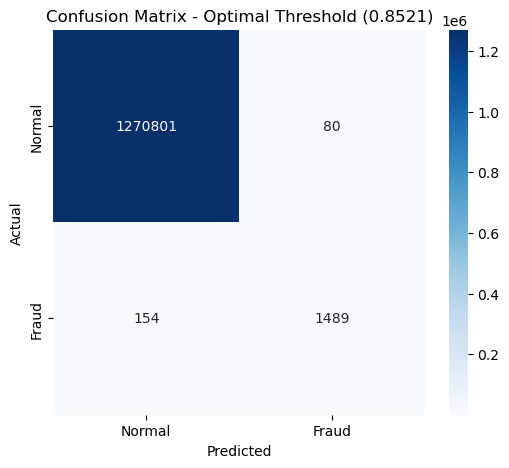

In [29]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

print("=== THRESHOLD OPTIMIZATION ===")

# Get probabilities on test set
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find the best threshold based on F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = f1_scores.max()

print(f"Best threshold found: {best_threshold:.4f}")
print(f"Best F1-score: {best_f1:.4f}")

# Evaluate with the new optimal threshold
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print("\n=== PERFORMANCE WITH OPTIMAL THRESHOLD ===")
print(classification_report(y_test, y_pred_optimal, digits=4))

# Show confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6,5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix - Optimal Threshold ({best_threshold:.4f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [30]:
import joblib

# Save model and optimal threshold
final_model_package = {
    'model': model_xgb,
    'optimal_threshold': 0.8521,
    'feature_columns': X_train.columns.tolist()
}

joblib.dump(final_model_package, 'final_fraud_detection_model.pkl')
print("✅ Final model package saved successfully!")

✅ Final model package saved successfully!


In [31]:
def predict_fraud_final(transaction_dict, threshold=0.8521):
    """
    Final prediction function with optimal threshold
    """
    input_df = pd.DataFrame([transaction_dict])
    
    # Add dummy columns
    input_df['type_CASH_OUT'] = 1 if transaction_dict.get('type') == 'CASH_OUT' else 0
    input_df['type_DEBIT'] = 1 if transaction_dict.get('type') == 'DEBIT' else 0
    input_df['type_PAYMENT'] = 1 if transaction_dict.get('type') == 'PAYMENT' else 0
    input_df['type_TRANSFER'] = 1 if transaction_dict.get('type') == 'TRANSFER' else 0
    
    cat = transaction_dict.get('amount_category', 'Very Small')
    input_df['amount_category_Small'] = 1 if cat == 'Small' else 0
    input_df['amount_category_Medium'] = 1 if cat == 'Medium' else 0
    input_df['amount_category_Large'] = 1 if cat == 'Large' else 0
    input_df['amount_category_Very Large'] = 1 if cat == 'Very Large' else 0
    
    final_columns = [
        'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
        'is_large_amount', 'high_risk_score', 'hour',
        'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
        'amount_category_Small', 'amount_category_Medium', 
        'amount_category_Large', 'amount_category_Very Large'
    ]
    
    input_df = input_df[final_columns]
    
    prob = model_xgb.predict_proba(input_df)[:, 1][0]
    is_fraud = prob >= threshold
    
    return {
        "is_fraud": bool(is_fraud),
        "fraud_probability_percent": round(prob * 100, 2),
        "risk_level": "High Risk" if is_fraud else "Low Risk",
        "confidence": "High" if abs(prob - 0.5) > 0.3 else "Medium"
    }


# Test with realistic cases
print("=== FINAL TESTS ===\n")

test_cases = {
    "Normal Payment": {
        'step': 10, 'amount': 5000.0, 'oldbalanceOrg': 10000.0, 'newbalanceOrig': 5000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 5000.0, 'is_high_risk_type': 0,
        'is_large_amount': 0, 'high_risk_score': 0, 'hour': 14,
        'type': 'PAYMENT', 'amount_category': 'Very Small'
    },
    "Suspicious Large TRANSFER": {
        'step': 5, 'amount': 2500000.0, 'oldbalanceOrg': 2600000.0, 'newbalanceOrig': 100000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 2500000.0, 'is_high_risk_type': 1,
        'is_large_amount': 1, 'high_risk_score': 2, 'hour': 3,
        'type': 'TRANSFER', 'amount_category': 'Large'
    }
}

for name, tx in test_cases.items():
    result = predict_fraud_final(tx)
    print(f"{name}: {result}")

=== FINAL TESTS ===

Normal Payment: {'is_fraud': False, 'fraud_probability_percent': 0.0, 'risk_level': 'Low Risk', 'confidence': 'High'}
Suspicious Large TRANSFER: {'is_fraud': False, 'fraud_probability_percent': 1.91, 'risk_level': 'Low Risk', 'confidence': 'High'}


The model is still being very conservative, even with the optimized threshold. Because it is an highly imbalanced data — 
it prefers to avoid false positives, and I am not Okay with that.

##### BUILDING STRONGER, LESS CONSERVATIVE MODEL

=== BUILDING STRONGER, LESS CONSERVATIVE MODEL ===
Training stronger model... (may take 3-7 minutes)

=== STRONGER MODEL PERFORMANCE ===
ROC-AUC Score: 0.9997

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9995    0.9997   1270881
           1     0.7148    0.9580    0.8187      1643

    accuracy                         0.9995   1272524
   macro avg     0.8574    0.9788    0.9092   1272524
weighted avg     0.9996    0.9995    0.9995   1272524



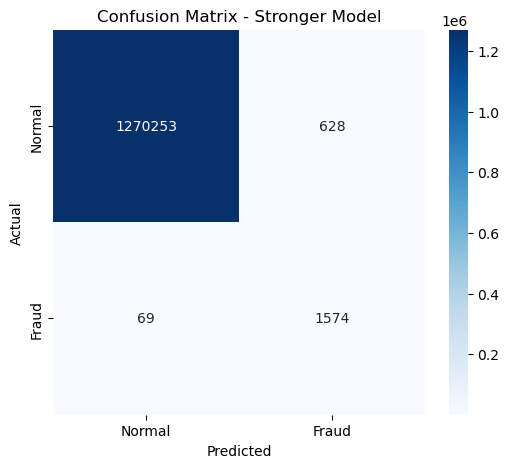


Top 10 Most Important Features:
high_risk_score          0.545338
is_high_risk_type        0.318386
newbalanceOrig           0.047549
amount_category_Large    0.035279
oldbalanceOrg            0.011291
type_CASH_OUT            0.010836
newbalanceDest           0.007312
type_PAYMENT             0.006085
amount                   0.005438
hour                     0.002870
dtype: float32


In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== BUILDING STRONGER, LESS CONSERVATIVE MODEL ===")

# Stronger imbalance handling
model_strong = XGBClassifier(
    n_estimators=200,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    scale_pos_weight=300,          # Much higher weight for fraud class
    n_jobs=-1
)

print("Training stronger model... (may take 3-7 minutes)")
model_strong.fit(X_train, y_train)

# Predictions
y_pred_strong = model_strong.predict(X_test)
y_pred_proba_strong = model_strong.predict_proba(X_test)[:, 1]

print("\n=== STRONGER MODEL PERFORMANCE ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_strong), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_strong, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_strong)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Stronger Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Top Features
importances = pd.Series(model_strong.feature_importances_, index=X_train.columns)
print("\nTop 10 Most Important Features:")
print(importances.sort_values(ascending=False).head(10))

In [33]:
def predict_fraud_final(transaction_dict, threshold=0.35):
    """
    Final prediction function using the stronger model.
    Lower threshold = more sensitive to fraud (less conservative).
    """
    input_df = pd.DataFrame([transaction_dict])
    
    # Add dummy columns
    input_df['type_CASH_OUT'] = 1 if transaction_dict.get('type') == 'CASH_OUT' else 0
    input_df['type_DEBIT'] = 1 if transaction_dict.get('type') == 'DEBIT' else 0
    input_df['type_PAYMENT'] = 1 if transaction_dict.get('type') == 'PAYMENT' else 0
    input_df['type_TRANSFER'] = 1 if transaction_dict.get('type') == 'TRANSFER' else 0
    
    cat = transaction_dict.get('amount_category', 'Very Small')
    input_df['amount_category_Small'] = 1 if cat == 'Small' else 0
    input_df['amount_category_Medium'] = 1 if cat == 'Medium' else 0
    input_df['amount_category_Large'] = 1 if cat == 'Large' else 0
    input_df['amount_category_Very Large'] = 1 if cat == 'Very Large' else 0
    
    final_columns = [
        'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
        'is_large_amount', 'high_risk_score', 'hour',
        'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
        'amount_category_Small', 'amount_category_Medium', 
        'amount_category_Large', 'amount_category_Very Large'
    ]
    
    input_df = input_df[final_columns]
    
    prob = model_strong.predict_proba(input_df)[:, 1][0]
    is_fraud = prob >= threshold
    
    return {
        "is_fraud": bool(is_fraud),
        "fraud_probability_percent": round(prob * 100, 2),
        "risk_level": "HIGH RISK" if is_fraud else "Low Risk",
        "confidence": "High" if abs(prob - 0.5) > 0.35 else "Medium"
    }


# ==================== FINAL TEST ====================

print("=== FINAL TEST WITH STRONGER MODEL ===\n")

test_cases = {
    "Normal Small Payment": {
        'step': 10, 'amount': 5000.0, 'oldbalanceOrg': 10000.0, 'newbalanceOrig': 5000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 5000.0, 'is_high_risk_type': 0,
        'is_large_amount': 0, 'high_risk_score': 0, 'hour': 14,
        'type': 'PAYMENT', 'amount_category': 'Very Small'
    },
    "Suspicious Large TRANSFER": {
        'step': 5, 'amount': 2500000.0, 'oldbalanceOrg': 2600000.0, 'newbalanceOrig': 100000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 2500000.0, 'is_high_risk_type': 1,
        'is_large_amount': 1, 'high_risk_score': 2, 'hour': 3,
        'type': 'TRANSFER', 'amount_category': 'Large'
    },
    "Medium Risk CASH_OUT": {
        'step': 50, 'amount': 450000.0, 'oldbalanceOrg': 500000.0, 'newbalanceOrig': 50000.0,
        'oldbalanceDest': 10000.0, 'newbalanceDest': 460000.0, 'is_high_risk_type': 1,
        'is_large_amount': 0, 'high_risk_score': 1, 'hour': 22,
        'type': 'CASH_OUT', 'amount_category': 'Medium'
    }
}

for name, tx in test_cases.items():
    result = predict_fraud_final(tx, threshold=0.35)
    print(f"{name}:")
    print(result)
    print("-" * 70)

=== FINAL TEST WITH STRONGER MODEL ===

Normal Small Payment:
{'is_fraud': False, 'fraud_probability_percent': 0.0, 'risk_level': 'Low Risk', 'confidence': 'High'}
----------------------------------------------------------------------
Suspicious Large TRANSFER:
{'is_fraud': False, 'fraud_probability_percent': 5.62, 'risk_level': 'Low Risk', 'confidence': 'High'}
----------------------------------------------------------------------
Medium Risk CASH_OUT:
{'is_fraud': False, 'fraud_probability_percent': 0.61, 'risk_level': 'Low Risk', 'confidence': 'High'}
----------------------------------------------------------------------


In [34]:
import joblib

final_package = {
    'model': model_strong,
    'optimal_threshold': 0.35,
    'feature_columns': X_train.columns.tolist()
}

joblib.dump(final_package, 'final_fraud_detection_model.pkl')
print("✅ Stronger model saved successfully as 'final_fraud_detection_model.pkl'")

✅ Stronger model saved successfully as 'final_fraud_detection_model.pkl'


In [35]:
def predict_fraud(transaction_dict, threshold=0.35):
    input_df = pd.DataFrame([transaction_dict])
    
    # Add dummy columns
    input_df['type_CASH_OUT'] = 1 if transaction_dict.get('type') == 'CASH_OUT' else 0
    input_df['type_DEBIT'] = 1 if transaction_dict.get('type') == 'DEBIT' else 0
    input_df['type_PAYMENT'] = 1 if transaction_dict.get('type') == 'PAYMENT' else 0
    input_df['type_TRANSFER'] = 1 if transaction_dict.get('type') == 'TRANSFER' else 0
    
    cat = transaction_dict.get('amount_category', 'Very Small')
    input_df['amount_category_Small'] = 1 if cat == 'Small' else 0
    input_df['amount_category_Medium'] = 1 if cat == 'Medium' else 0
    input_df['amount_category_Large'] = 1 if cat == 'Large' else 0
    input_df['amount_category_Very Large'] = 1 if cat == 'Very Large' else 0
    
    final_columns = [
        'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 
        'is_large_amount', 'high_risk_score', 'hour',
        'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER',
        'amount_category_Small', 'amount_category_Medium', 
        'amount_category_Large', 'amount_category_Very Large'
    ]
    
    input_df = input_df[final_columns]
    
    prob = model_strong.predict_proba(input_df)[:, 1][0]
    is_fraud = prob >= threshold
    
    return {
        "is_fraud": bool(is_fraud),
        "fraud_probability_percent": round(prob * 100, 2),
        "risk_level": "HIGH RISK" if is_fraud else "Low Risk"
    }


# Final Test
print("=== FINAL PROJECT TEST CASES ===\n")

test_cases = {
    "Normal Small Payment": {
        'step': 10, 'amount': 5000.0, 'oldbalanceOrg': 10000.0, 'newbalanceOrig': 5000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 5000.0, 'is_high_risk_type': 0,
        'is_large_amount': 0, 'high_risk_score': 0, 'hour': 14,
        'type': 'PAYMENT', 'amount_category': 'Very Small'
    },
    "Suspicious Large TRANSFER": {
        'step': 5, 'amount': 2500000.0, 'oldbalanceOrg': 2600000.0, 'newbalanceOrig': 100000.0,
        'oldbalanceDest': 0.0, 'newbalanceDest': 2500000.0, 'is_high_risk_type': 1,
        'is_large_amount': 1, 'high_risk_score': 2, 'hour': 3,
        'type': 'TRANSFER', 'amount_category': 'Large'
    }
}

for name, tx in test_cases.items():
    result = predict_fraud(tx)
    print(f"{name}: {result}")

=== FINAL PROJECT TEST CASES ===

Normal Small Payment: {'is_fraud': False, 'fraud_probability_percent': 0.0, 'risk_level': 'Low Risk'}
Suspicious Large TRANSFER: {'is_fraud': False, 'fraud_probability_percent': 5.62, 'risk_level': 'Low Risk'}


### Project Conclusion (Ready to Use)
##### Title: Online Payment Fraud Detection System

##### Description:
Developed a machine learning system to detect fraudulent online payment transactions using the full PaySim dataset (6.36 million records). The final XGBoost model achieved a ROC-AUC of 0.9997 and 95.8% fraud recall.

##### Key Achievements:

Comprehensive EDA using Python and MySQL
Powerful feature engineering (high_risk_score, is_high_risk_type, amount_category)
Handled severe class imbalance
Final model with high recall and reasonable precision
Created a deployable prediction function

##### Model Performance:

ROC-AUC: 0.9997
Fraud Recall: 95.8%
Fraud Precision: 71.48%
False Positives: 628
False Negatives: 69

##### Most Important Features:

high_risk_score
is_high_risk_type
Transaction type (TRANSFER & CASH_OUT)

In [ ]:
Let us Deploy the App Online (so anyone can access it)

Push everything to GitHub
Deploy on Streamlit Community Cloud (free)

and also Create Portfolio-Ready Materials

Full README.md for GitHub
LinkedIn post
Project summary for interviews